<a href="https://www.kaggle.com/code/izzarsulynashrudin/classificationnihchestxrays?scriptVersionId=300942083" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Overview Project

Project ini menggunakan data NIH Chest XRays untuk klasifikasi penyakit dan deteksi objek penyakit. Berikut adalah metode yang akan digunakan dalam penelitian:

| Metode | Tugas                      | Metric Utama     |
| ------ | -------------------------- | ---------------- |
| CNN    | Multi-label classification | PR-AUC / ROC-AUC |
| ResNet | Multi-label classification | PR-AUC / ROC-AUC |
| YOLO   | Object detection           | mAP@0.5          | 

Penggunaan Kaggle sendiri untuk membantu kerja model dikarena menggunakan dataset yang cukup besar sebanyak 112120 gambar sehingga membutuhkan akselerator GPU untuk peningkatan performa model serta membutuhkan waktu yang lama untuk menjalankan model ini. Oleh karena itu, saya berterima kasih atas pihak-pihak yang telah membantu dalam penelitian ini.


[Izzar Suly Nashrudin}


# Instalisasi Package

In [8]:
import os
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Preprocessing

## Set Path Dataset

In [9]:
datasetPath = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"
bboxPath = "/kaggle/input/datasets/organizations/nih-chest-xrays/data/BBox_List_2017.csv"

print(os.listdir(datasetPath)[:20])

['images_003', 'images_012', 'LOG_CHESTXRAY.pdf', 'README_CHESTXRAY.pdf', 'BBox_List_2017.csv', 'images_009', 'images_008', 'images_007', 'test_list.txt', 'images_010', 'ARXIV_V5_CHESTXRAY.pdf', 'images_002', 'images_011', 'Data_Entry_2017.csv', 'images_001', 'train_val_list.txt', 'images_005', 'FAQ_CHESTXRAY.pdf', 'images_004', 'images_006']


## Load dan Bersihkan Data Label

In [12]:
labelDf = pd.read_csv(os.path.join(datasetPath, "Data_Entry_2017.csv"))

labelDf = labelDf.loc[:, ~labelDf.columns.str.contains("^Unnamed")]

labelDf = labelDf.rename(columns={
    "Image Index": "imageIndex",
    "Finding Labels": "findingLabels",
    "Follow-up #": "followUpNumber",
    "Patient ID": "patientId",
    "Patient Age": "patientAge",
    "Patient Gender": "patientGender",
    "View Position": "viewPosition",
    "OriginalImage[Width": "originalImageWidth",
    "Height]": "originalImageHeight",
    "OriginalImagePixelSpacing[x": "originalImagePixelSpacingX",
    "y]": "originalImagePixelSpacingY"
})

labelDf.head()

,imageIndex,findingLabels,followUpNumber,patientId,patientAge,patientGender,viewPosition,originalImageWidth,originalImageHeight,originalImagePixelSpacingX,originalImagePixelSpacingY
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143


## Rapikan Tipe Data

In [14]:
numericColumns = [
    "followUpNumber",
    "patientId",
    "patientAge",
    "originalImageWidth",
    "originalImageHeight",
    "originalImagePixelSpacingX",
    "originalImagePixelSpacingY"
]

for columnName in numericColumns:
    labelDf[columnName] = pd.to_numeric(labelDf[columnName], errors="coerce")

labelDf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112120 entries, 0 to 112119
Data columns (total 11 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   imageIndex                  112120 non-null  object 
 1   findingLabels               112120 non-null  object 
 2   followUpNumber              112120 non-null  int64  
 3   patientId                   112120 non-null  int64  
 4   patientAge                  112120 non-null  int64  
 5   patientGender               112120 non-null  object 
 6   viewPosition                112120 non-null  object 
 7   originalImageWidth          112120 non-null  int64  
 8   originalImageHeight         112120 non-null  int64  
 9   originalImagePixelSpacingX  112120 non-null  float64
 10  originalImagePixelSpacingY  112120 non-null  float64
dtypes: float64(2), int64(5), object(4)
memory usage: 9.4+ MB


## Buat Label List dan Target Labels

In [15]:
labelDf["labelList"] = labelDf["findingLabels"].str.split("|")

allLabels = sorted({
    labelName
    for labelList in labelDf["labelList"]
    for labelName in labelList
})

targetLabels = sorted([
    labelName
    for labelName in allLabels
    if labelName != "No Finding"
])

print(targetLabels)
print("Total target labels:", len(targetLabels))

['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']
Total target labels: 14


## Multi-Label Encoding

In [16]:
for labelName in targetLabels:
    labelDf[labelName] = labelDf["labelList"].apply(
        lambda currentLabels: int(labelName in currentLabels)
    )

labelDf["noFinding"] = labelDf["findingLabels"].apply(
    lambda x: 1 if x == "No Finding" else 0
)

labelDf.head()

,imageIndex,findingLabels,followUpNumber,patientId,patientAge,patientGender,viewPosition,originalImageWidth,originalImageHeight,originalImagePixelSpacingX,...,Emphysema,Fibrosis,Hernia,Infiltration,Mass,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax,noFinding
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,...,0,0,0,0,0,0,0,0,0,0
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,...,1,0,0,0,0,0,0,0,0,0
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,...,0,0,0,0,0,0,0,0,0,0
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,...,0,0,0,0,0,0,0,0,0,1
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,...,0,0,1,0,0,0,0,0,0,0


In [17]:
labelDf["labelList"]

0                    [Cardiomegaly]
1         [Cardiomegaly, Emphysema]
2          [Cardiomegaly, Effusion]
3                      [No Finding]
4                          [Hernia]
                    ...            
112115            [Mass, Pneumonia]
112116                 [No Finding]
112117                 [No Finding]
112118                 [No Finding]
112119                 [No Finding]
Name: labelList, Length: 112120, dtype: object

## Kumpulkan Semua Path Gambar

In [20]:
imageFolderPaths = []

for folderName in os.listdir(datasetPath):
    if folderName.startswith("images_"):
        folderPath = os.path.join(datasetPath, folderName, "images")
        if os.path.isdir(folderPath):
            imageFolderPaths.append(folderPath)

imageFolderPaths = sorted(imageFolderPaths)
print(imageFolderPaths)

['/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_001/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_002/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_004/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_005/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_006/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_007/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_008/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_009/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_010/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_011/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_012/images']


## Buat DataFrame Path Gambar

In [21]:
imageRows = []

for folderPath in imageFolderPaths:
    for imageName in os.listdir(folderPath):
        imageRows.append({
            "imageIndex": imageName,
            "imagePath": os.path.join(folderPath, imageName)
        })

imagePathDf = pd.DataFrame(imageRows)

print(imagePathDf.shape)
imagePathDf.head()

(112120, 2)


,imageIndex,imagePath
0,00000502_003.png,/kaggle/input/datasets/organizations/nih-chest...
1,00001255_008.png,/kaggle/input/datasets/organizations/nih-chest...
2,00001304_001.png,/kaggle/input/datasets/organizations/nih-chest...
3,00000003_003.png,/kaggle/input/datasets/organizations/nih-chest...
4,00000926_002.png,/kaggle/input/datasets/organizations/nih-chest...


## Merge Label + Path

In [22]:
masterDf = labelDf.merge(imagePathDf, on="imageIndex", how="left")
masterDf = masterDf.dropna(subset=["imagePath"]).reset_index(drop=True)

print(masterDf.shape)
print("Missing imagePath:", masterDf["imagePath"].isna().sum())
masterDf.head()

(112120, 28)
Missing imagePath: 0


,imageIndex,findingLabels,followUpNumber,patientId,patientAge,patientGender,viewPosition,originalImageWidth,originalImageHeight,originalImagePixelSpacingX,...,Fibrosis,Hernia,Infiltration,Mass,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax,noFinding,imagePath
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,...,0,0,0,0,0,0,0,0,0,/kaggle/input/datasets/organizations/nih-chest...
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,...,0,0,0,0,0,0,0,0,0,/kaggle/input/datasets/organizations/nih-chest...
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,...,0,0,0,0,0,0,0,0,0,/kaggle/input/datasets/organizations/nih-chest...
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,...,0,0,0,0,0,0,0,0,1,/kaggle/input/datasets/organizations/nih-chest...
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,...,0,1,0,0,0,0,0,0,0,/kaggle/input/datasets/organizations/nih-chest...


## EDA Singkat

In [23]:
print("Total images:", len(masterDf))
print("Total patients:", masterDf["patientId"].nunique())

labelCounts = masterDf[targetLabels].sum().sort_values(ascending=False)
print(labelCounts)

Total images: 112120
Total patients: 30805
Infiltration          19894
Effusion              13317
Atelectasis           11559
Nodule                 6331
Mass                   5782
Pneumothorax           5302
Consolidation          4667
Pleural_Thickening     3385
Cardiomegaly           2776
Emphysema              2516
Edema                  2303
Fibrosis               1686
Pneumonia              1431
Hernia                  227
dtype: int64


Plot overview dataset

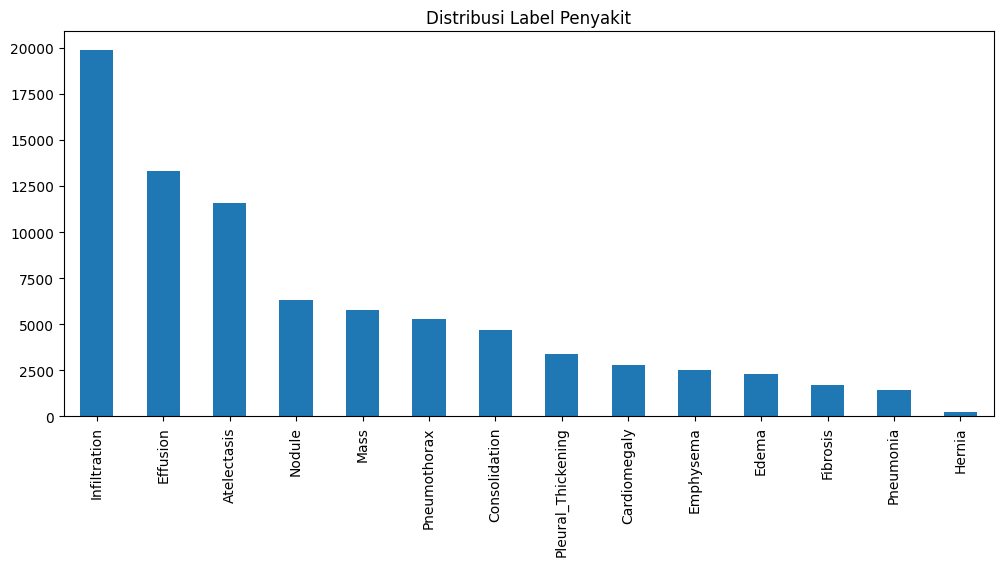

In [24]:
labelCounts.plot(kind="bar", figsize=(12, 5))
plt.title("Distribusi Label Penyakit")
plt.show()

# Training

## Split Data Patient-Wise

In [27]:
patientIds = masterDf["patientId"].dropna().unique()

trainPatients, tempPatients = train_test_split(
    patientIds,
    test_size=0.30,
    random_state=42
)

validPatients, testPatients = train_test_split(
    tempPatients,
    test_size=0.50,
    random_state=42
)

trainDf = masterDf[masterDf["patientId"].isin(trainPatients)].reset_index(drop=True)
validDf = masterDf[masterDf["patientId"].isin(validPatients)].reset_index(drop=True)
testDf = masterDf[masterDf["patientId"].isin(testPatients)].reset_index(drop=True)

print("Train shape:", trainDf.shape)
print("Valid shape:", validDf.shape)
print("Test shape:", testDf.shape)

Train shape: (78566, 28)
Valid shape: (17063, 28)
Test shape: (16491, 28)


## Siapkan Dataset TensorFlow

Gunakan ACCELERATOR untuk akses GPU dan CUDA

In [31]:
imageSize = (224, 224)
batchSize = 32
autoTune = tf.data.AUTOTUNE

def decodeImage(imagePath):
    imageBytes = tf.io.read_file(imagePath)
    image = tf.image.decode_png(imageBytes, channels=3)
    image = tf.image.resize(image, imageSize)
    image = tf.cast(image, tf.float32) / 255.0
    return image

def makeDataset(dataDf, shuffle=True):
    xPaths = dataDf["imagePath"].values
    yLabels = dataDf[targetLabels].values.astype(np.float32)

    ds = tf.data.Dataset.from_tensor_slices((xPaths, yLabels))

    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(dataDf), 10000), reshuffle_each_iteration=True)

    def mapFn(path, y):
        x = decodeImage(path)
        return x, y

    ds = ds.map(mapFn, num_parallel_calls=autoTune)
    ds = ds.batch(batchSize).prefetch(autoTune)
    return ds

trainDs = makeDataset(trainDf, shuffle=True)
validDs = makeDataset(validDf, shuffle=False)
testDs = makeDataset(testDf, shuffle=False)

print(trainDs)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 14), dtype=tf.float32, name=None))>


# Model Convolutional Neural Network (CNN)

In [32]:
numClasses = len(targetLabels)

cnnModel = keras.Sequential([
    layers.Input(shape=(imageSize[0], imageSize[1], 3)),
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPool2D(),
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPool2D(),
    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.MaxPool2D(),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(numClasses, activation="sigmoid")
])

cnnModel.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="binaryAccuracy", threshold=0.5),
        keras.metrics.AUC(name="rocAuc"),
        keras.metrics.AUC(name="prAuc", curve="PR"),
        keras.metrics.Precision(name="precision", thresholds=0.5),
        keras.metrics.Recall(name="recall", thresholds=0.5),
    ]
)

cnnModel.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         3,598 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,870 (507.30 KB)

 Trainable params: 129,870 (507.30 KB)

 Non-trainable params: 0 (0.00 B)

## Training CNN

In [ ]:
cnnCallbacks = [
    keras.callbacks.ModelCheckpoint("cnnBest.keras", monitor="val_prAuc", mode="max", save_best_only=True),
    keras.callbacks.EarlyStopping(monitor="val_prAuc", mode="max", patience=3, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_prAuc", mode="max", factor=0.5, patience=2)
]

cnnHistory = cnnModel.fit(
    trainDs,
    validation_data=validDs,
    epochs=10,
    callbacks=cnnCallbacks
)

## Evaluasi CNN

In [ ]:
cnnEval = cnnModel.evaluate(testDs)
print(cnnEval)

# Model Residual Network (ResNet)

In [33]:
baseModel = keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(imageSize[0], imageSize[1], 3)
)

baseModel.trainable = False

inputs = keras.Input(shape=(imageSize[0], imageSize[1], 3))
x = keras.applications.resnet.preprocess_input(inputs * 255.0)
x = baseModel(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(targetLabels), activation="sigmoid")(x)

resnetModel = keras.Model(inputs, outputs)

resnetModel.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.AUC(name="rocAuc"),
        keras.metrics.AUC(name="prAuc", curve="PR"),
        keras.metrics.Precision(name="precision", thresholds=0.5),
        keras.metrics.Recall(name="recall", thresholds=0.5),
    ]
)

resnetModel.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ multiply[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ multiply[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 14)        │     28,686 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,616,398 (90.09 MB)

 Trainable params: 28,686 (112.05 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Training ResNet Tahap 1

In [ ]:
resnetCallbacks = [
    keras.callbacks.ModelCheckpoint("resnetFrozenBest.keras", monitor="val_prAuc", mode="max", save_best_only=True),
    keras.callbacks.EarlyStopping(monitor="val_prAuc", mode="max", patience=2, restore_best_weights=True)
]

resnetHistory1 = resnetModel.fit(
    trainDs,
    validation_data=validDs,
    epochs=5,
    callbacks=resnetCallbacks
)

## Fine-Tuning ResNet

In [ ]:
baseModel.trainable = True

for layer in baseModel.layers[:-30]:
    layer.trainable = False

resnetModel.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.AUC(name="rocAuc"),
        keras.metrics.AUC(name="prAuc", curve="PR"),
        keras.metrics.Precision(name="precision", thresholds=0.5),
        keras.metrics.Recall(name="recall", thresholds=0.5),
    ]
)

resnetHistory2 = resnetModel.fit(
    trainDs,
    validation_data=validDs,
    epochs=10,
    callbacks=[
        keras.callbacks.ModelCheckpoint("resnetFineTuneBest.keras", monitor="val_prAuc", mode="max", save_best_only=True),
        keras.callbacks.EarlyStopping(monitor="val_prAuc", mode="max", patience=3, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_prAuc", mode="max", factor=0.5, patience=2)
    ]
)

## Evaluasi ResNet

In [ ]:
resnetEval = resnetModel.evaluate(testDs)
print(resnetEval)

# Model You Only Look Once (YOLO)

## Load Bounding Box

In [35]:
bboxDf = pd.read_csv(bboxPath)
bboxDf = bboxDf.iloc[:, :6].copy()
bboxDf.columns = ["imageIndex", "className", "x", "y", "w", "h"]

for columnName in ["x", "y", "w", "h"]:
    bboxDf[columnName] = pd.to_numeric(bboxDf[columnName], errors="coerce")

bboxDf.head()

,imageIndex,className,x,y,w,h
0,00013118_008.png,Atelectasis,225.084746,547.019217,86.779661,79.186441
1,00014716_007.png,Atelectasis,686.101695,131.543498,185.491525,313.491525
2,00029817_009.png,Atelectasis,221.830508,317.053115,155.118644,216.949153
3,00014687_001.png,Atelectasis,726.237288,494.951420,141.016949,55.322034
4,00017877_001.png,Atelectasis,660.067797,569.780787,200.677966,78.101695


## Merge Bounding Box + Image Path + Patient

In [36]:
bboxMergedDf = bboxDf.merge(imagePathDf, on="imageIndex", how="left")
bboxMergedDf = bboxMergedDf.merge(
    labelDf[["imageIndex", "patientId", "originalImageWidth", "originalImageHeight"]],
    on="imageIndex",
    how="left"
)

bboxMergedDf = bboxMergedDf.dropna(subset=["imagePath"]).reset_index(drop=True)

print(bboxMergedDf.shape)
bboxMergedDf.head()

(984, 10)


,imageIndex,className,x,y,w,h,imagePath,patientId,originalImageWidth,originalImageHeight
0,00013118_008.png,Atelectasis,225.084746,547.019217,86.779661,79.186441,/kaggle/input/datasets/organizations/nih-chest...,13118,2992,2991
1,00014716_007.png,Atelectasis,686.101695,131.543498,185.491525,313.491525,/kaggle/input/datasets/organizations/nih-chest...,14716,3056,2544
2,00029817_009.png,Atelectasis,221.830508,317.053115,155.118644,216.949153,/kaggle/input/datasets/organizations/nih-chest...,29817,3056,2544
3,00014687_001.png,Atelectasis,726.237288,494.951420,141.016949,55.322034,/kaggle/input/datasets/organizations/nih-chest...,14687,2500,2048
4,00017877_001.png,Atelectasis,660.067797,569.780787,200.677966,78.101695,/kaggle/input/datasets/organizations/nih-chest...,17877,2500,2048


## Split YOLO Data

In [39]:
bboxPatientIds = bboxMergedDf["patientId"].dropna().unique()

trainPatientsYolo, tempPatientsYolo = train_test_split(
    bboxPatientIds,
    test_size=0.30,
    random_state=42
)

validPatientsYolo, testPatientsYolo = train_test_split(
    tempPatientsYolo,
    test_size=0.50,
    random_state=42
)

trainBboxDf = bboxMergedDf[bboxMergedDf["patientId"].isin(trainPatientsYolo)].reset_index(drop=True)
validBboxDf = bboxMergedDf[bboxMergedDf["patientId"].isin(validPatientsYolo)].reset_index(drop=True)
testBboxDf = bboxMergedDf[bboxMergedDf["patientId"].isin(testPatientsYolo)].reset_index(drop=True)

print(trainBboxDf.shape, validBboxDf.shape, testBboxDf.shape)

(684, 10) (160, 10) (140, 10)


## Mapping Class YOLO

In [40]:
classNames = sorted(bboxMergedDf["className"].dropna().unique().tolist())
classToId = {name: index for index, name in enumerate(classNames)}

print(classToId)

{'Atelectasis': 0, 'Cardiomegaly': 1, 'Effusion': 2, 'Infiltrate': 3, 'Mass': 4, 'Nodule': 5, 'Pneumonia': 6, 'Pneumothorax': 7}


## Buat Folder YOLO

In [45]:
yoloRootPath = Path("/kaggle/working/nihYolo")

for splitName in ["train", "val", "test"]:
    (yoloRootPath / "images" / splitName).mkdir(parents=True, exist_ok=True)
    (yoloRootPath / "labels" / splitName).mkdir(parents=True, exist_ok=True)

## Konversi ke Format YOLO

In [46]:
def writeYoloSplit(splitDf, splitName):
    groupedDf = splitDf.groupby("imageIndex")

    for imageIndex, groupDf in groupedDf:
        imagePath = groupDf["imagePath"].iloc[0]
        imageWidth = float(groupDf["originalImageWidth"].iloc[0])
        imageHeight = float(groupDf["originalImageHeight"].iloc[0])

        outputImagePath = yoloRootPath / "images" / splitName / imageIndex
        outputLabelPath = yoloRootPath / "labels" / splitName / (Path(imageIndex).stem + ".txt")

        shutil.copy(imagePath, outputImagePath)

        yoloLines = []
        for _, row in groupDf.iterrows():
            classId = classToId[row["className"]]

            x = float(row["x"])
            y = float(row["y"])
            w = float(row["w"])
            h = float(row["h"])

            xCenter = (x + w / 2.0) / imageWidth
            yCenter = (y + h / 2.0) / imageHeight
            widthNorm = w / imageWidth
            heightNorm = h / imageHeight

            yoloLines.append(
                f"{classId} {xCenter:.6f} {yCenter:.6f} {widthNorm:.6f} {heightNorm:.6f}"
            )

        outputLabelPath.write_text("\n".join(yoloLines))

writeYoloSplit(trainBboxDf, "train")
writeYoloSplit(validBboxDf, "val")
writeYoloSplit(testBboxDf, "test")

## Buat data.yaml

In [47]:
dataYamlPath = yoloRootPath / "data.yaml"

yamlText = f"""path: {str(yoloRootPath)}
train: images/train
val: images/val
test: images/test

names:
"""

for index, className in enumerate(classNames):
    yamlText += f"  {index}: {className}\n"

dataYamlPath.write_text(yamlText)
print(yamlText)

path: /kaggle/working/nihYolo
train: images/train
val: images/val
test: images/test

names:
  0: Atelectasis
  1: Cardiomegaly
  2: Effusion
  3: Infiltrate
  4: Mass
  5: Nodule
  6: Pneumonia
  7: Pneumothorax



## Install dan Train YOLO

In [49]:
!pip -q install ultralytics

In [ ]:
from ultralytics import YOLO

yoloModel = YOLO("yolov8n.pt")

yoloModel.train(
    data=str(dataYamlPath),
    imgsz=640,
    epochs=50,
    batch=16,
    device=0
)

## Evaluasi YOLO

In [ ]:
yoloMetrics = yoloModel.val(data=str(dataYamlPath))
print(yoloMetrics)